In [4]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg

Choix considérés : bin_size = 50 ms, threshold = 45%

In [5]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml'
session = '/mnt/hubel-data-140/karadoc/Rat004_20240318/Rat004_20240318.xml'
R = rg.data.Regions(session, ids=["nr"], states=['sws', 'rem'])

In [12]:
"""
avalanche_comparison.py
=======================
Comparative analysis of neuronal avalanches across brain states.

Supported comparisons
---------------------
1. sws  vs  non-sws  (other)
2. swsISR  vs  swsnonISR   (sws windows with / without InfraSlowRhythm)

For each condition pair the module produces:
  - P(S >= s) CCDF with power-law fit  (log-log)
  - Scalar metrics panel :
        tau_size,  tau_dur,
        gamma = (tau_dur - 1) / (tau_size - 1),
        tau_gamma_scaling  (expected from scaling relation),
        DCC = |tau_rapport - tau_gamma|
  - Statistical comparison :
        Z-test on tau_size / tau_dur between the two conditions
        KS two-sample test on raw size / duration distributions

Usage
-----
    from avalanche_comparison import AvalancheComparison

    # --- comparison 1 : sws vs other ---
    cmp = AvalancheComparison(session, bin_size=0.05, threshold=3)
    cmp.run_sws_vs_other(region="nr")
    fig = cmp.plot()
    fig.savefig("sws_vs_other.pdf")

    # --- comparison 2 : swsISR vs swsnonISR ---
    cmp2 = AvalancheComparison(session, bin_size=0.05, threshold=3)
    cmp2.run_swsISR_vs_swsnonISR(region="nr")
    fig2 = cmp2.plot()
    fig2.savefig("swsISR_vs_swsnonISR.pdf")
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import ks_2samp
import powerlaw
from powerlaw import Fit
from scipy.optimize import OptimizeWarning

# ── try to import the project-level modules (adjust paths as needed) ──────────
import regions as rg        # noqa: F401  – used via rg.data.Regions


# ═══════════════════════════════════════════════════════════════════════════════
#  DATA CLASSES
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class AvalancheResult:
    """Holds the full result for one brain-state condition."""
    label: str
    sizes:         np.ndarray            # raw avalanche sizes  (n,)
    durations:     np.ndarray            # raw avalanche durations (n,)
    # ── power-law fit on sizes ─────────────────────────────────────────────
    tau_size:      float = np.nan
    sigma_size:    float = np.nan
    xmin_size:     float = np.nan
    xmax_size:     float = np.nan
    R_size:        float = np.nan        # log-likelihood ratio vs exponential
    p_size:        float = np.nan
    ntail_size:    float = np.nan
    # ── power-law fit on durations ─────────────────────────────────────────
    tau_dur:       float = np.nan
    sigma_dur:     float = np.nan
    xmin_dur:      float = np.nan
    xmax_dur:      float = np.nan
    R_dur:         float = np.nan
    p_dur:         float = np.nan
    ntail_dur:     float = np.nan
    # ── derived criticality metrics ────────────────────────────────────────
    gamma_empirical:     float = np.nan   # (tau_dur-1)/(tau_size-1)
    tau_gamma_scaling:   float = np.nan   # from <S>~D^gamma  (direct regression)
    DCC:                 float = np.nan   # |tau_rapport - tau_gamma|

    # colour used in plots (set by AvalancheComparison)
    color: str = "C0"


@dataclass
class ComparisonStats:
    """Statistical comparison between two AvalancheResult objects."""
    # Z-tests (tau_A - tau_B) / sqrt(sigma_A^2 + sigma_B^2)
    z_tau_size:   float = np.nan
    p_z_tau_size: float = np.nan
    z_tau_dur:    float = np.nan
    p_z_tau_dur:  float = np.nan
    # KS two-sample
    ks_size:   float = np.nan
    p_ks_size: float = np.nan
    ks_dur:    float = np.nan
    p_ks_dur:  float = np.nan
    # difference in derived metrics
    delta_gamma:         float = np.nan
    delta_tau_scaling:   float = np.nan
    delta_DCC:           float = np.nan


# ═══════════════════════════════════════════════════════════════════════════════
#  LOW-LEVEL HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def _powerlaw_fit(data: np.ndarray, xmin: Optional[float] = None, xmax: Optional[float] = None):
    """
    Fit a discrete power law via Clauset et al. 2009 (MLE).

    Returns
    -------
    tau, sigma, xmin, xmax, R_vs_exp, p_vs_exp, n_tail_proportion, ks_stat, r2
    All NaN on failure.
    """
    data = np.asarray(data, dtype=float)
    print(len(data), "avalanches for power-law fit", len(np.unique(data)), "unique values")
    data = data[data >= 1]

    nans = (np.nan,) * 7

    if len(np.unique(data)) < 2 or len(data) < 20:
        print("DATA TOO SMALL OR NOT ENOUGH UNIQUE VALUES FOR POWER-LAW FIT", len(data), np.unique(data))
        return nans

    data_int = data.astype(int)
    data_int = data_int[data_int >= 1]

    unique_vals = np.unique(data_int)
    if len(unique_vals) < 4:
        print("NOT ENOUGH UNIQUE VALUES FOR POWER-LAW FIT", unique_vals, len(data_int))
        return nans

    most_common_freq = np.max(np.bincount(data_int)) / len(data_int)
    if most_common_freq > 0.90:
        print("MOST COMMON VALUE TOO PREVALENT FOR POWER-LAW FIT")
        return nans

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)
        warnings.simplefilter("ignore", UserWarning)
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            # pour améliorer le fit je fixe xmin et xmax
            if xmax is not None:
                xmax = int(np.percentile(data_int, xmax)) #Convert percentile to actual value  
            fit = Fit(data_int, xmin = xmin, xmax=xmax, discrete=True, verbose=False)
        except Exception:
            return nans

    tau   = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin  = fit.xmin
    xmax  = fit.xmax if fit.xmax is not None else np.max(data_int)
    n_tail_prop = fit.n_tail / len(data)

    if np.isnan(tau):
        return nans

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r, p = fit.distribution_compare(
            'power_law', 'exponential', normalized_ratio=True
        )

        #tail = data_int[data_int >= xmin]
        tail = data_int[(data_int >= xmin) & (data_int <= xmax)]

        theoretical = fit.power_law.cdf(np.sort(tail))
        empirical   = np.arange(1, len(tail)+1) / len(tail)
        ks_stat     = float(np.max(np.abs(empirical - theoretical)))

    # R² en log-log sur la queue fittée
        x_ccdf, y_ccdf = _ccdf(tail)
        log_x = np.log(x_ccdf)
        log_y = np.log(y_ccdf + 1e-12)
        valid = np.isfinite(log_x) & np.isfinite(log_y)
        if valid.sum() > 2:
            y_pred = np.polyval(np.polyfit(log_x[valid], log_y[valid], 1), log_x[valid])
            ss_res = np.sum((log_y[valid] - y_pred)**2)
            ss_tot = np.sum((log_y[valid] - log_y[valid].mean())**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        else:
            r2 = np.nan

    return tau, sigma, xmin, xmax, r, p, n_tail_prop, ks_stat, r2


def _ccdf(data: np.ndarray):
    """Compute empirical CCDF P(X >= x)."""
    data = np.sort(data)
    n    = len(data)
    ccdf = 1.0 - np.arange(1, n + 1) / n   # P(X >= x)  (right-continuous)
    return data, ccdf


def _z_test_tau(tau_a, sigma_a, tau_b, sigma_b):
    """
    Two-sided Z-test H0: tau_A == tau_B.
    sigma_a/b are standard errors from MLE.
    Returns (z, p_two_sided).
    """
    from scipy.stats import norm
    se = np.sqrt(sigma_a**2 + sigma_b**2)
    if se == 0 or np.isnan(se):
        return np.nan, np.nan
    z = (tau_a - tau_b) / se
    p = 2 * norm.sf(np.abs(z))
    return float(z), float(p)


def _gamma_from_scaling(sizes: np.ndarray, durations: np.ndarray) -> float:
    """
    Estimate gamma via OLS regression of log<S|D> on log D.
    Returns slope (= gamma), or NaN.
    """
    sizes     = np.asarray(sizes,     dtype=float)
    durations = np.asarray(durations, dtype=float)

    valid = (sizes >= 1) & (durations >= 1)
    S, D  = sizes[valid], durations[valid]

    unique_D = np.unique(D)
    if len(unique_D) < 4:
        return np.nan

    mean_S = np.array([S[D == d].mean() for d in unique_D])
    log_D  = np.log(unique_D)
    log_S  = np.log(mean_S)

    keep = np.isfinite(log_D) & np.isfinite(log_S)
    if keep.sum() < 4:
        return np.nan

    gamma, _ = np.polyfit(log_D[keep], log_S[keep], 1)
    return float(gamma)


def _fit_avalanche_result(
    label: str,
    sizes: np.ndarray,
    durations: np.ndarray,
    color: str = "C0",
    xmin: Optional[float] = None,
    xmax: Optional[float] = None
) -> AvalancheResult:
    """Run all fits and derive criticality metrics for one condition."""
    res = AvalancheResult(
        label=label,
        sizes=np.asarray(sizes, dtype=float),
        durations=np.asarray(durations, dtype=float),
        color=color,
    )

    print("Sizes Fit")

    (res.tau_size, res.sigma_size, res.xmin_size,
     res.xmax_size, res.R_size, res.p_size, res.ntail_size, res.ks_size, res.r2_size) = _powerlaw_fit(sizes, xmin=xmin, xmax=xmax)
    
    print("Durations Fit")

    (res.tau_dur, res.sigma_dur, res.xmin_dur,
     res.xmax_dur, res.R_dur, res.p_dur, res.ntail_dur, res.ks_dur, res.r2_dur) = _powerlaw_fit(durations, xmin=xmin, xmax=xmax)

    # gamma empirical from tau exponents
    if not (np.isnan(res.tau_size) or np.isnan(res.tau_dur)):
        denom = res.tau_size - 1
        if denom != 0:
            res.gamma_empirical = (res.tau_dur - 1) / denom

    # gamma from <S>~D^gamma scaling relation
    res.tau_gamma_scaling = _gamma_from_scaling(sizes, durations)

    # DCC = distance from criticality criterion
    if not (np.isnan(res.gamma_empirical) or np.isnan(res.tau_gamma_scaling)):
        res.DCC = abs(res.gamma_empirical - res.tau_gamma_scaling)

    return res


def _compare_two(a: AvalancheResult, b: AvalancheResult) -> ComparisonStats:
    """Compute all statistical comparisons between two conditions."""
    stats = ComparisonStats()

    # ── Z-tests on tau ────────────────────────────────────────────────────
    stats.z_tau_size, stats.p_z_tau_size = _z_test_tau(
        a.tau_size, a.sigma_size, b.tau_size, b.sigma_size
    )
    stats.z_tau_dur, stats.p_z_tau_dur = _z_test_tau(
        a.tau_dur, a.sigma_dur, b.tau_dur, b.sigma_dur
    )

    # ── KS two-sample tests ───────────────────────────────────────────────
    def _ks(x, y):
        x = np.asarray(x); y = np.asarray(y)
        x = x[np.isfinite(x) & (x >= 1)]
        y = y[np.isfinite(y) & (y >= 1)]
        if len(x) < 5 or len(y) < 5:
            return np.nan, np.nan
        res = ks_2samp(x, y)
        return float(res.statistic), float(res.pvalue)

    stats.ks_size,  stats.p_ks_size = _ks(a.sizes,     b.sizes)
    stats.ks_dur,   stats.p_ks_dur  = _ks(a.durations, b.durations)

    # ── differences in derived metrics ───────────────────────────────────
    stats.delta_gamma       = a.gamma_empirical   - b.gamma_empirical
    stats.delta_tau_scaling = a.tau_gamma_scaling - b.tau_gamma_scaling
    stats.delta_DCC         = a.DCC               - b.DCC

    return stats


# ═══════════════════════════════════════════════════════════════════════════════
#  MAIN CLASS
# ═══════════════════════════════════════════════════════════════════════════════

class AvalancheComparison:
    """
    High-level API for comparing avalanche statistics across brain states.

    Parameters
    ----------
    session       : neuroscience session object understood by rg.data.Regions
    bin_size      : float  — bin size (s) passed to get_avalanches
    threshold     : float  — threshold passed to get_avalanches
    get_avalanches: callable(FR, bin_size, threshold) -> (sizes, durations)
                    If None, the module will look for a globally available
                    `get_avalanches` function.
    """

    COLORS = {
        "sws":         "#2166ac",
        "other":       "#d6604d",
        "swsISR":      "#1a9850",
        "swsnonISR":   "#d73027",
    }

    def __init__(
        self,
        session,
        bin_size:       float = 0.05,
        threshold:      float = 30.0,
        get_avalanches=None,
    ):
        self.session      = session
        self.bin_size     = bin_size
        self.threshold    = threshold

        if get_avalanches is None:
            import builtins
            get_avalanches = getattr(builtins, "get_avalanches", None)
            if get_avalanches is None:
                # last resort: look in caller's global namespace
                import inspect
                frame = inspect.stack()[1][0]
                get_avalanches = frame.f_globals.get("get_avalanches")
        if get_avalanches is None:
            raise ValueError(
                "No get_avalanches function found. "
                "Pass it explicitly: AvalancheComparison(session, …, get_avalanches=fn)"
            )
        self._get_avalanches = get_avalanches

        self.results:  list[AvalancheResult] = []
        self.stats:    Optional[ComparisonStats] = None
        self._title:   str = ""

    # ── spike / FR helpers ────────────────────────────────────────────────────

    def _avalanches_for(self, FR):
        sizes, durations = self._get_avalanches(FR, self.bin_size, self.threshold)
        return np.asarray(sizes, dtype=float), np.asarray(durations, dtype=float)

    # ── public run methods ────────────────────────────────────────────────────

    def run_sws_vs_other(self, region: str = "nr", xmin: Optional[float] = None, xmax: Optional[float] = None):
        """
        Compare SWS avalanches vs non-SWS (other) avalanches.
        """
        self._title = f"SWS vs Other — [{region}]"

        R = rg.data.Regions(self.session, states=['sws'], events=['InfraSlowRhythm/slownr'])

        # SWS
        FR_sws = R.firingRate(regs=[region], states="sws", shift=True)
        s_sws, d_sws = self._avalanches_for(FR_sws)

        # Other (non-sws) — use state='other' if supported, else 'wake'
        try:
            FR_other = R.firingRate(regs=[region], states="other", shift=True)
        except Exception:
            FR_other = R.firingRate(regs=[region], states="wake", shift=True)
        s_other, d_other = self._avalanches_for(FR_other)

        print("SWS :", len(s_sws), len(d_sws))
        print("Other :", len(s_other), len(d_other))

        self.results = [
            _fit_avalanche_result("SWS",   s_sws,   d_sws,   self.COLORS["sws"], xmin=xmin, xmax=xmax),
            _fit_avalanche_result("Other", s_other, d_other, self.COLORS["other"], xmin=xmin, xmax=xmax),
        ]
        self.stats = _compare_two(*self.results)
        return self

    def run_swsISR_vs_swsnonISR(self, region: str = "nr", xmin: Optional[float] = None, xmax: Optional[float] = None):
        """
        Compare SWS-ISR avalanches vs SWS-non-ISR avalanches.
        nonISR = sws windows EXCLUDING InfraSlowRhythm events.
        """
        self._title = f"SWS-ISR vs SWS-nonISR — [{region}]"

        R = rg.data.Regions(self.session, states=['sws','rem'], events=['InfraSlowRhythm/slownr'])

        # ISR windows: Regions with events="InfraSlowRythm"  (typo in original API)
        FR_full = R.firingRate(regs=['nr'], states='sws', shift=False)
        sws_ISR = R.eventIntervals([["sws"],["slownr"]])
        FR_isr    = fma.general.restrict(FR_full, sws_ISR,    shift=True)
        s_isr, d_isr = self._avalanches_for(FR_isr)

        # non-ISR: sws WITHOUT events keyword (full sws), then subtract ISR
        # Some rg implementations accept a negation flag; we handle both cases.
        FR_full = R.firingRate(regs=['nr'], states='sws', shift=False)
        isr_intervals = R.eventIntervals('slownr')
        sws_intervals = R.states['sws']
        sws_nonISR = fma.general.subtractIntervals(sws_intervals, isr_intervals)
        FR_nonisr = fma.general.restrict(FR_full, sws_nonISR, shift=True)
        s_nonisr, d_nonisr = self._avalanches_for(FR_nonisr)

        print("SWS-ISR :", len(s_isr), len(d_isr))
        print("SWS-nonISR :", len(s_nonisr), len(d_nonisr))

        self.results = [
            _fit_avalanche_result("SWS-ISR",    s_isr,    d_isr,    self.COLORS["swsISR"], xmin=xmin, xmax=xmax),
            _fit_avalanche_result("SWS-nonISR", s_nonisr, d_nonisr, self.COLORS["swsnonISR"], xmin=xmin, xmax=xmax),
        ]
        self.stats = _compare_two(*self.results)
        return self

    # ── plotting ──────────────────────────────────────────────────────────────

    def plot(self, figsize=(16, 10)) -> plt.Figure:
        """
        Generate the full comparison figure.

        Layout
        ------
        Row 0 :  CCDF size (A)  |  CCDF duration (B)
        Row 1 :  Metrics bar chart (C)   |   Stats table (D)
        """
        if not self.results:
            raise RuntimeError("Call run_*() before plot().")

        fig = plt.figure(figsize=figsize, constrained_layout=True)
        fig.suptitle(self._title, fontsize=14, fontweight="bold", y=1.01)

        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
        ax_size  = fig.add_subplot(gs[0, 0])
        ax_dur   = fig.add_subplot(gs[0, 1])
        ax_met   = fig.add_subplot(gs[1, 0])
        ax_stat  = fig.add_subplot(gs[1, 1])

        self._plot_ccdf(ax_size, which="size")
        self._plot_ccdf(ax_dur,  which="duration")
        self._plot_metrics(ax_met)
        self._plot_stats_table(ax_stat)

        return fig

    # ── internal plot helpers ─────────────────────────────────────────────────

    def _plot_ccdf(self, ax: plt.Axes, which: str = "size"):
        """Log-log CCDF + power-law fit for sizes or durations."""
        is_size = (which == "size")
        for res in self.results:
            raw  = res.sizes     if is_size else res.durations
            tau  = res.tau_size  if is_size else res.tau_dur
            xmin = res.xmin_size if is_size else res.xmin_dur
            xmax = res.xmax_size if is_size else res.xmax_dur

            raw = raw[np.isfinite(raw) & (raw >= 1)]
            if len(raw) < 5:
                continue

            x_ccdf, y_ccdf = _ccdf(raw)
            ax.plot(x_ccdf, y_ccdf, ".", color=res.color,
                    alpha=0.4, markersize=3, rasterized=True)

            # ── power-law line in the fitted range ──────────────────────
            if np.isfinite(tau) and np.isfinite(xmin):
                xs  = np.logspace(np.log10(xmin), np.log10(xmax), 200)
                # normalise so that the line passes through the CCDF at xmin
                idx   = np.searchsorted(x_ccdf, xmin)
                y0    = y_ccdf[min(idx, len(y_ccdf) - 1)]
                slope = -(tau - 1)
                ys    = y0 * (xs / xmin) ** slope
                R_val = res.R_size if is_size else res.R_dur
                p_val = res.p_size if is_size else res.p_dur
                ks_val = res.ks_size  if is_size else res.ks_dur
                r2_val = res.r2_size  if is_size else res.r2_dur

                label = (f"{res.label}  τ={tau:.2f}±{(res.sigma_size if is_size else res.sigma_dur):.2f}"
                         f"\n[xmin={xmin:.0f}, xmax={xmax:.0f}, xmin/xmax={xmin/xmax:.2f}, n_tail={res.ntail_size:.1%}]"
                         f"\n[R={R_val:.2f}, p_vs_exp={p_val:.3f}, KS={ks_val:.3f}, R²={r2_val:.3f}]")
                ax.axvline(xmin, color=res.color, linewidth=0.8, linestyle=':', alpha=0.7)
                ax.axvline(xmax, color=res.color, linewidth=0.8, linestyle='--', alpha=0.5)
                ax.plot(xs, ys, "-", color=res.color, linewidth=2, label=label)

        xlabel = "Avalanche size $s$" if is_size else "Avalanche duration $d$"
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(r"$P(S \geq s)$" if is_size else r"$P(D \geq d)$", fontsize=11)
        ax.set_title("Size CCDF" if is_size else "Duration CCDF", fontsize=12)
        ax.legend(fontsize=9, framealpha=0.7)
        ax.grid(True, which="both", alpha=0.25, linestyle="--")

    def _plot_metrics(self, ax: plt.Axes):
        """Grouped bar chart of criticality metrics per condition."""
        metrics = [
            ("γ emp.\n(τ_dur-1)/(τ_size-1)", "gamma_empirical"),
            ("γ scaling\n⟨S⟩~D^γ",            "tau_gamma_scaling"),
            ("DCC\n|γ_emp - γ_scal|",          "DCC"),
        ]
        n_metrics = len(metrics)
        n_cond    = len(self.results)
        width     = 0.8 / n_cond
        x         = np.arange(n_metrics)

        for i, res in enumerate(self.results):
            vals = [getattr(res, attr) for _, attr in metrics]
            offset = (i - (n_cond - 1) / 2) * width
            bars = ax.bar(x + offset, vals, width * 0.9,
                          color=res.color, label=res.label, alpha=0.85,
                          edgecolor="white", linewidth=0.5)
            for bar, v in zip(bars, vals):
                if np.isfinite(v):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.01,
                            f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

        ax.set_xticks(x)
        ax.set_xticklabels([m for m, _ in metrics], fontsize=9.5)
        ax.set_ylabel("Value", fontsize=11)
        ax.set_title("Criticality metrics", fontsize=12)
        ax.legend(fontsize=9, framealpha=0.7)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.grid(axis="y", alpha=0.25, linestyle="--")

    def _plot_stats_table(self, ax: plt.Axes):
        """Table summarising all statistical tests."""
        ax.axis("off")
        if self.stats is None:
            return

        s  = self.stats
        la = self.results[0].label
        lb = self.results[1].label

        def _fmt(v):
            return f"{v:.4f}" if np.isfinite(v) else "—"

        def _star(p):
            if not np.isfinite(p): return ""
            if p < 0.001: return "***"
            if p < 0.01:  return "**"
            if p < 0.05:  return "*"
            return "n.s."

        rows = [
            ["Test", "Statistic", "p-value", "Sig."],
            # ── Z-tests ──────────────────────────────────────────────
            [f"Z-test τ_size\n({la} vs {lb})",
             f"z={_fmt(s.z_tau_size)}", _fmt(s.p_z_tau_size), _star(s.p_z_tau_size)],
            [f"Z-test τ_dur\n({la} vs {lb})",
             f"z={_fmt(s.z_tau_dur)}", _fmt(s.p_z_tau_dur), _star(s.p_z_tau_dur)],
            # ── KS tests ─────────────────────────────────────────────
            [f"KS sizes\n({la} vs {lb})",
             f"D={_fmt(s.ks_size)}", _fmt(s.p_ks_size), _star(s.p_ks_size)],
            [f"KS durations\n({la} vs {lb})",
             f"D={_fmt(s.ks_dur)}", _fmt(s.p_ks_dur), _star(s.p_ks_dur)],
            # ── metric diffs ─────────────────────────────────────────
            [f"Δγ empirical\n({la}−{lb})",
             f"{_fmt(s.delta_gamma)}", "—", ""],
            [f"Δγ scaling\n({la}−{lb})",
             f"{_fmt(s.delta_tau_scaling)}", "—", ""],
            [f"ΔDCC\n({la}−{lb})",
             f"{_fmt(s.delta_DCC)}", "—", ""],
        ]

        col_widths = [0.38, 0.24, 0.20, 0.10]
        n_rows     = len(rows)
        row_h      = 1.0 / n_rows

        for r_idx, row in enumerate(rows):
            y = 1.0 - (r_idx + 0.5) * row_h
            is_header = (r_idx == 0)
            x_cursor  = 0.0

            # row background
            bg = "#e8e8e8" if is_header else ("#f7f7f7" if r_idx % 2 == 0 else "white")
            rect = plt.Rectangle((0, 1.0 - (r_idx + 1) * row_h),
                                  1.0, row_h,
                                  transform=ax.transAxes,
                                  color=bg, zorder=0, clip_on=False)
            ax.add_patch(rect)

            for c_idx, (cell, cw) in enumerate(zip(row, col_widths)):
                xc = x_cursor + cw / 2
                fw = "bold" if is_header else "normal"
                fs = 8.5 if is_header else 8

                # colour p-value column based on significance
                fc = "black"
                if c_idx == 2 and not is_header:
                    try:
                        pv = float(cell)
                        if pv < 0.001:   fc = "#006d2c"
                        elif pv < 0.01:  fc = "#31a354"
                        elif pv < 0.05:  fc = "#74c476"
                        else:            fc = "#d73027"
                    except ValueError:
                        pass

                ax.text(xc, y, cell, ha="center", va="center",
                        fontsize=fs, fontweight=fw, color=fc,
                        transform=ax.transAxes, wrap=True,
                        multialignment="center")
                x_cursor += cw

        # outer border
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title("Statistical comparison", fontsize=12, pad=6)

    # ── convenience: print summary ────────────────────────────────────────────

    def summary(self):
        """Print a text summary of all metrics and comparisons."""
        print(f"\n{'='*60}")
        print(f"  {self._title}")
        print(f"{'='*60}")
        for res in self.results:
            print(f"\n  ── {res.label} (n={len(res.sizes)}) ──")
            print(f"     τ_size          = {res.tau_size:.4f} ± {res.sigma_size:.4f}"
                  f"   (xmin={res.xmin_size}, p_vs_exp={res.p_size:.3f})")
            print(f"     τ_dur           = {res.tau_dur:.4f} ± {res.sigma_dur:.4f}"
                  f"   (xmin={res.xmin_dur}, p_vs_exp={res.p_dur:.3f})")
            print(f"     γ empirical     = {res.gamma_empirical:.4f}")
            print(f"     γ scaling       = {res.tau_gamma_scaling:.4f}")
            print(f"     DCC             = {res.DCC:.4f}")

        if self.stats:
            s = self.stats
            la, lb = self.results[0].label, self.results[1].label
            print(f"\n  ── Statistical tests ({la} vs {lb}) ──")
            print(f"     Z τ_size  z={s.z_tau_size:.3f}  p={s.p_z_tau_size:.4f}")
            print(f"     Z τ_dur   z={s.z_tau_dur:.3f}  p={s.p_z_tau_dur:.4f}")
            print(f"     KS sizes  D={s.ks_size:.3f}   p={s.p_ks_size:.4f}")
            print(f"     KS durs   D={s.ks_dur:.3f}    p={s.p_ks_dur:.4f}")
        print()


# ═══════════════════════════════════════════════════════════════════════════════
#  BATCH HELPER  – run both comparisons for a list of sessions
# ═══════════════════════════════════════════════════════════════════════════════

def run_all_comparisons(
    sessions: list,
    bin_size:       float = 0.05,
    threshold:      float = 3.0,
    region:         str   = "nr",
    get_avalanches=None,
    save_dir:       Optional[str] = None,
) -> dict[str, list]:
    """
    Run both sws-vs-other and swsISR-vs-swsnonISR for every session.

    Returns
    -------
    dict with keys "sws_vs_other" and "swsISR_vs_swsnonISR",
    each mapping to a list of AvalancheComparison objects.

    If save_dir is given, figures are saved as PDF there.
    """
    import os

    out = {"sws_vs_other": [], "swsISR_vs_swsnonISR": []}

    for i, sess in enumerate(sessions):
        print(f"[{i+1}/{len(sessions)}] {sess}")

        for key, run_fn in [
            ("sws_vs_other",       lambda c: c.run_sws_vs_other(region)),
            ("swsISR_vs_swsnonISR", lambda c: c.run_swsISR_vs_swsnonISR(region)),
        ]:
            try:
                cmp = AvalancheComparison(
                    sess, bin_size=bin_size, threshold=threshold,
                    get_avalanches=get_avalanches,
                )
                run_fn(cmp)
                out[key].append(cmp)

                if save_dir is not None:
                    os.makedirs(save_dir, exist_ok=True)
                    fname = os.path.join(save_dir, f"sess{i:03d}_{key}.pdf")
                    fig   = cmp.plot()
                    fig.savefig(fname, bbox_inches="tight")
                    plt.close(fig)
                    print(f"   saved → {fname}")

            except Exception as exc:
                warnings.warn(f"Session {i} [{key}] failed: {exc}", RuntimeWarning)

    return out

In [12]:
R = rg.data.Regions(session, states=['sws', 'rem'], events=['InfraSlowRhythm/slownr'])

shift=True

FR_sws_ISR = R.firingRate(regs=['nr'], states='sws', when='slownr', shift=True)

isr_intervals = R.eventIntervals('slownr')

all_intervals = R.eventIntervals('all')

print(isr_intervals[:1])
print(all_intervals[:3])

# 1. Intervalles sws
sws_intervals = R.states['sws']                        # (n, 2)

print(sws_intervals[:3])

# 3. sws \ ISR  =  soustraction
sws_nonISR = fma.general.subtractIntervals(sws_intervals, isr_intervals)

# Et pour ISR (intersection sws ∩ ISR)
sws_ISR = fma.general.intersectIntervals([sws_intervals, isr_intervals])
sws_ISR2 = R.eventIntervals([["sws"],["slownr"]])
print((sws_ISR==sws_ISR2).all())

# 4. Firing rate restreinte à ces intervalles
FR_full = R.firingRate(regs=['nr'], states='sws', shift=False)
print("FR full :", FR_full[:3])

FR_sws_nonISR = fma.general.restrict(FR_full, sws_nonISR, shift=shift)
FR_sws_ISR2    = fma.general.restrict(FR_full, sws_ISR,    shift=shift)
FR_sws_ISR3    = fma.general.restrict(FR_full, isr_intervals,   shift=shift)

FR4 = fma.general.restrict(FR_full, sws_intervals, shift=shift)
FR4 = fma.general.restrict(FR4, isr_intervals, shift=shift)

print(FR_sws_ISR[:3])
print(FR_sws_ISR2[:3])
print(FR_sws_ISR3[:3])

#print(FR_sws_ISR3==FR_sws_ISR)



[[1754.48 1780.22]]
[[    0.     27694.9888]]
[[1958. 2046.]
 [2070. 2146.]
 [2164. 2256.]]
True
FR full : [[1958.025   60.   ]
 [1958.075    0.   ]
 [1958.125    0.   ]]
[[0.045 0.   ]
 [0.095 0.   ]
 [0.145 0.   ]]
[[ 0.045 20.   ]
 [ 0.095  0.   ]
 [ 0.145  0.   ]]
[[86.905 20.   ]
 [86.955  0.   ]
 [87.005  0.   ]]


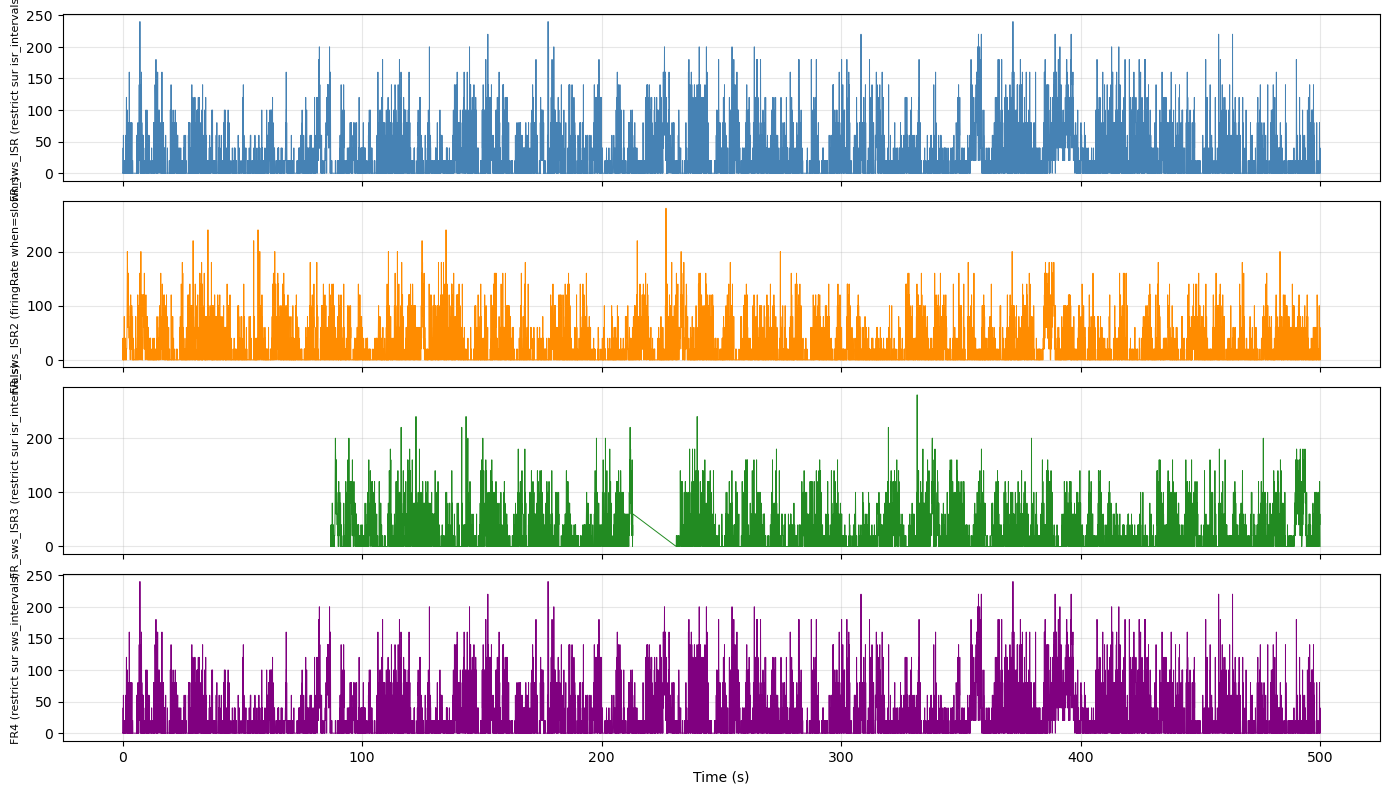

In [7]:
tmax = 500  # ajuster

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for ax, FR, label, color in zip(axes,
    [FR_sws_ISR, FR_sws_ISR2, FR_sws_ISR3, FR4],
    ['FR_sws_ISR (restrict sur isr_intervals)', 
     'FR_sws_ISR2 (firingRate when=slownr)', 
     'FR_sws_ISR3 (restrict sur isr_intervals)',
     'FR4 (restrict sur sws_intervals)'],
    ['steelblue', 'darkorange', 'forestgreen', 'purple']):
    
    mask = FR[:, 0] <= tmax
    ax.plot(FR[mask, 0], FR[mask, 1], color=color, linewidth=0.7)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [7]:
def get_avalanches(FR, bin_size, threshold):
    """
    Placeholder get_avalanches function.
    Replace with actual implementation that detects avalanches from FR matrix.
    """
    # For demonstration, return random data (replace with real detection logic)
    rates = FR[:, 1]
    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=threshold,
        time_step=bin_size,
        t0=FR[0, 0]
    )
    durations = (intervals[:, 1] - intervals[:, 0])/bin_size
    return size, durations

SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values
Durations Fit
66364 avalanches for power-law fit 319 unique values
SWS-ISR : 9114 9114
SWS-nonISR : 4420 4420
Sizes Fit
9114 avalanches for power-law fit 285 unique values
Durations Fit
9114 avalanches for power-law fit 260 unique values
Sizes Fit
4420 avalanches for power-law fit 342 unique values
Durations Fit
4420 avalanches for power-law fit 285 unique values


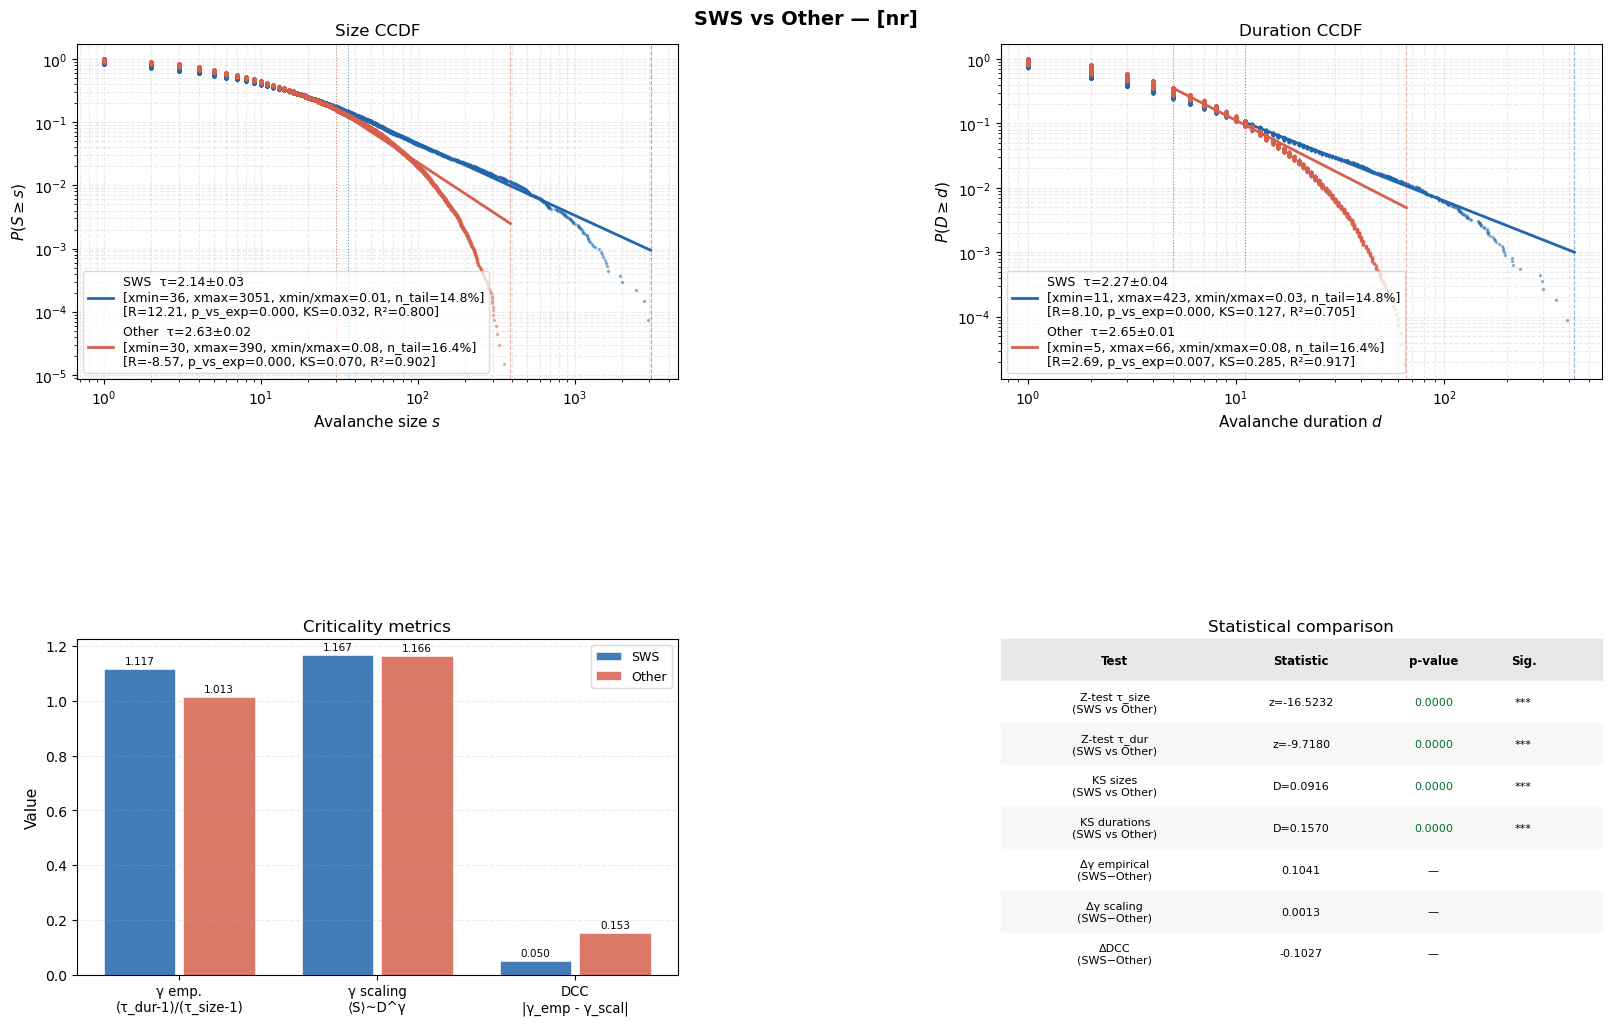

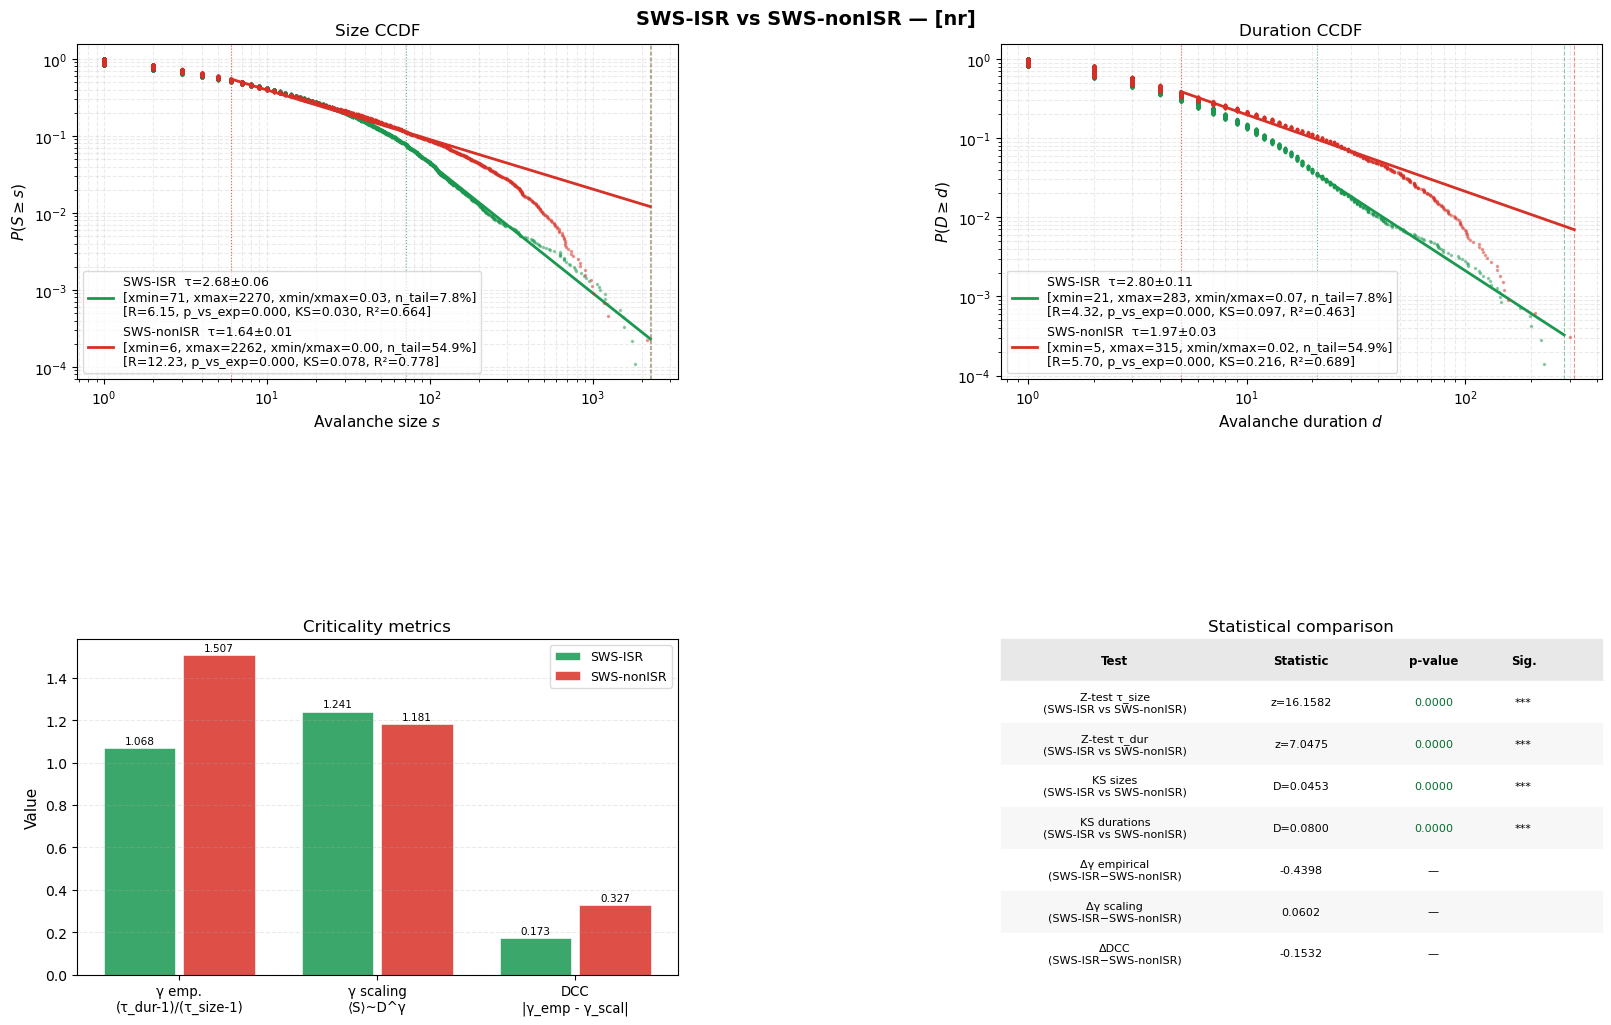

In [8]:

# SWS vs Other
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
bin_size = 0.05
threshold = 30

cmp = AvalancheComparison(session, bin_size=bin_size, threshold=threshold,
                           get_avalanches=get_avalanches)
cmp.run_sws_vs_other(region="nr", xmin=None, xmax=None)
fig = cmp.plot()

# SWS-ISR vs SWS-nonISR
cmp2 = AvalancheComparison(session, bin_size=bin_size, threshold=threshold,
                            get_avalanches=get_avalanches)
cmp2.run_swsISR_vs_swsnonISR(region="nr")
fig2 = cmp2.plot()

SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
66364 avalanches for power-law fit 319 unique values
xmax=95: DCC = 0.6577 - 0.5545
SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values


...

Durations Fit
66364 avalanches for power-law fit 319 unique values
xmax=99.5: DCC = 0.2735 - 0.1698
SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
66364 avalanches for power-law fit 319 unique values
xmax=99.9: DCC = 0.2560 - 0.4344
SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
66364 avalanches for power-law fit 319 unique values
xmax=99.99: DCC = 0.0813 - 0.3965
SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values
Durations Fit
66364 avalanches for power-law fit 319 unique values
xmax=None: DCC = 0.0500 - 0.1528
SWS : 13432 13432
Other : 66364 66364
Sizes Fit
13432 avalanches for power-law fit 429 unique values
Durations Fit
13432 avalanches for power-law fit 369 unique values
Sizes Fit
66364 avalanches for power-law fit 269 unique values
Durations Fit
66364 avalanches for power-law fit 319 unique values


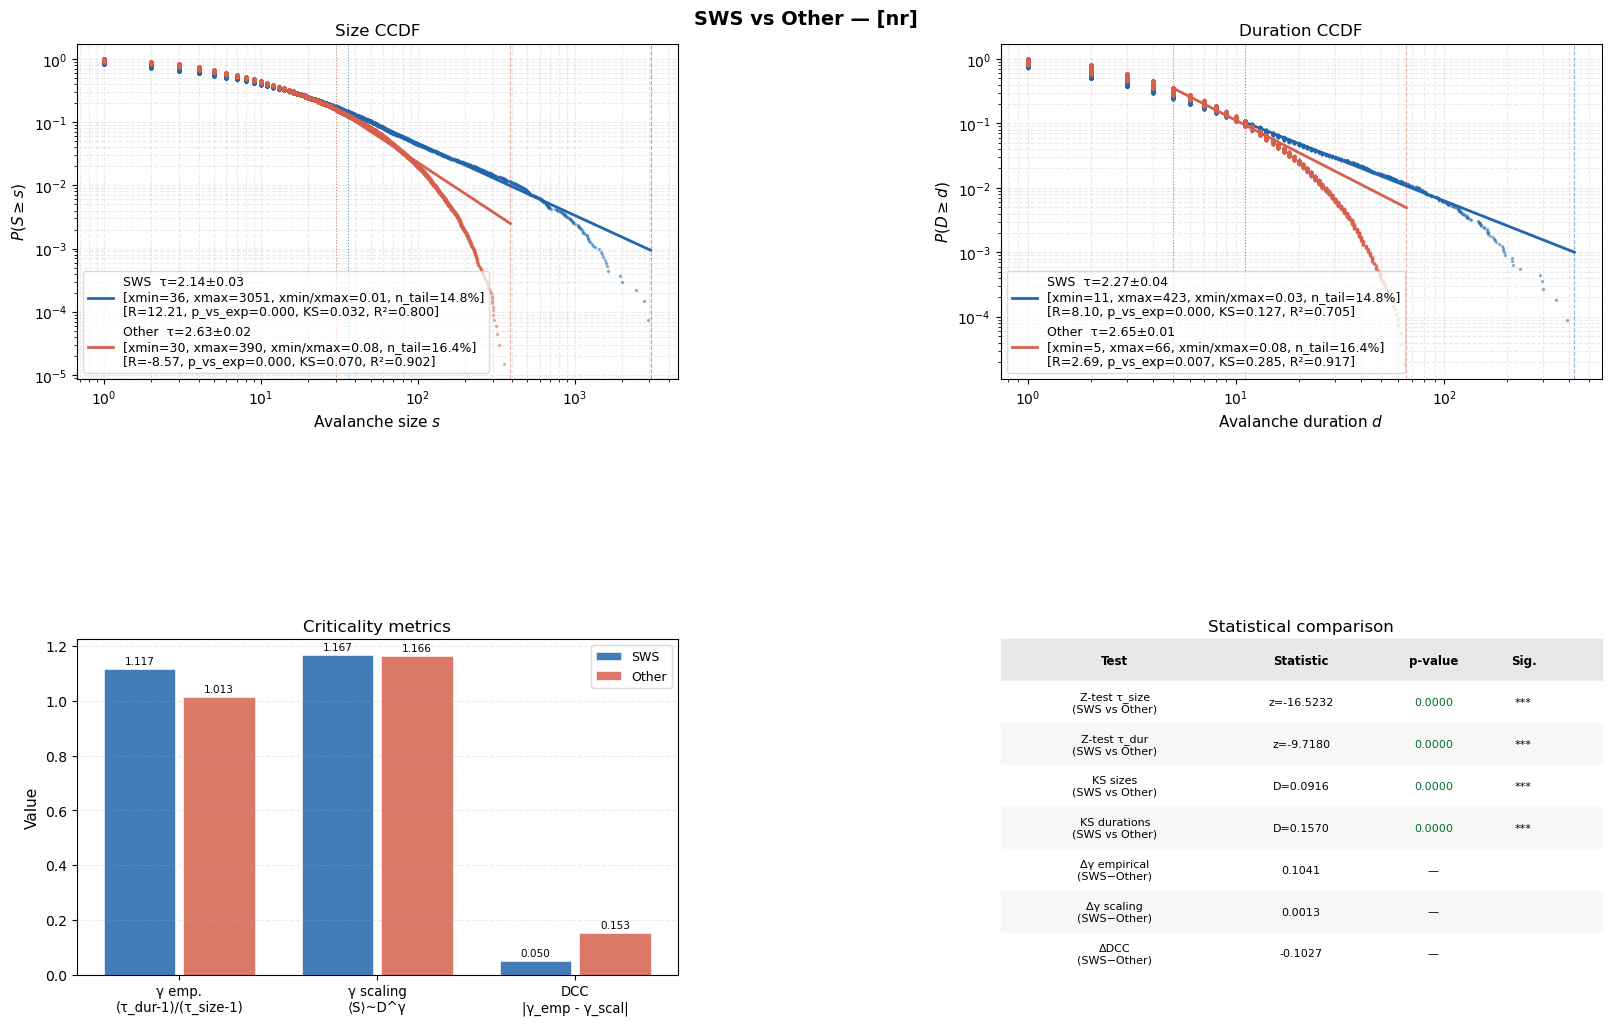

In [ ]:

# SWS vs Other
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
bin_size = 0.022
threshold = 30
xmin = None
xmax = None

cmp = AvalancheComparison(session, bin_size=bin_size, threshold=threshold,
                           get_avalanches=get_avalanches)
dcc = 1000
xmaxdef = None
for xmax in [95, 99, 99.5, 99.9, 99.99, None]:
    cmp.run_sws_vs_other(region="nr", xmin=xmin, xmax=xmax)
    if cmp.results[0].DCC is not None and cmp.results[1].DCC is not None:
        print(f"xmax={xmax}: DCC = {cmp.results[0].DCC:.4f} - {cmp.results[1].DCC:.4f}")
        if cmp.results[0].DCC < dcc:
            dcc = cmp.results[0].DCC
            xmaxdef = xmax
cmp.run_sws_vs_other(region="nr", xmin=xmin, xmax=xmaxdef)
fig = cmp.plot()

#cmp.run_swsISR_vs_swsnonISR(region="nr", xmin=xmin, xmax=xmax)
#fig2 = cmp.plot()

In [67]:
cmp.summary()


  SWS vs Other — [nr]

  ── SWS (n=13432) ──
     τ_size          = 2.0507 ± 0.0212   (xmin=29.0, p_vs_exp=0.000)
     τ_dur           = 1.9570 ± 0.0462   (xmin=23.0, p_vs_exp=0.004)
     γ empirical     = 0.9108
     γ scaling       = 1.1668
     DCC             = 0.2560

  ── Other (n=66364) ──
     τ_size          = 2.9880 ± 0.0325   (xmin=62.0, p_vs_exp=0.753)
     τ_dur           = 2.4535 ± 0.0106   (xmin=5.0, p_vs_exp=0.000)
     γ empirical     = 0.7312
     γ scaling       = 1.1655
     DCC             = 0.4344

  ── Statistical tests (SWS vs Other) ──
     Z τ_size  z=-24.166  p=0.0000
     Z τ_dur   z=-10.474  p=0.0000
     KS sizes  D=0.092   p=0.0000
     KS durs   D=0.157    p=0.0000



In [68]:
cmp2.summary()


  SWS-ISR vs SWS-nonISR — [nr]

  ── SWS-ISR (n=9114) ──
     τ_size          = 2.7591 ± 0.0751   (xmin=83.0, p_vs_exp=0.000)
     τ_dur           = 2.9635 ± 0.0932   (xmin=16.0, p_vs_exp=0.000)
     γ empirical     = 1.1162
     γ scaling       = 1.2409
     DCC             = 0.1248

  ── SWS-nonISR (n=4420) ──
     τ_size          = 1.5226 ± 0.0106   (xmin=6.0, p_vs_exp=0.000)
     τ_dur           = 1.8276 ± 0.0301   (xmin=9.0, p_vs_exp=0.003)
     γ empirical     = 1.5835
     γ scaling       = 1.1807
     DCC             = 0.4028

  ── Statistical tests (SWS-ISR vs SWS-nonISR) ──
     Z τ_size  z=16.293  p=0.0000
     Z τ_dur   z=11.601  p=0.0000
     KS sizes  D=0.045   p=0.0000
     KS durs   D=0.080    p=0.0000



SUR PLEIN DE SESSIONS

In [89]:
sessions =['/mnt/hubel-data-131/perceval/Rat003_20231229/Rat003_20231229.xml', '/mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml', '/mnt/hubel-data-131/perceval/Rat003_20231213/Rat003_20231213.xml', '/mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml', '/mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml', '/mnt/hubel-data-131/perceval/Rat003_20231216/Rat003_20231216.xml', '/mnt/hubel-data-131/perceval/Rat003_20231217/Rat003_20231217.xml', '/mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml', '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml', '/mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml', '/mnt/hubel-data-131/perceval/Rat003_20231222/Rat003_20231222.xml', '/mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240226/Rat004_20240226.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240228/Rat004_20240228.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240301/Rat004_20240301.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240302/Rat004_20240302.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240304/Rat004_20240304.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240305/Rat004_20240305.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240306/Rat004_20240306.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240307/Rat004_20240307.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240308/Rat004_20240308.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240309/Rat004_20240309.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240310/Rat004_20240310.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240311/Rat004_20240311.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240312/Rat004_20240312.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240313/Rat004_20240313.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240314/Rat004_20240314.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240315/Rat004_20240315.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240316/Rat004_20240316.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240317/Rat004_20240317.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240318/Rat004_20240318.xml', '/mnt/hubel-data-139/karadoc/Rat004_20240319/Rat004_20240319.xml']

In [98]:
results = run_all_comparisons(
    sessions=sessions,
    bin_size=bin_size,
    threshold=threshold,
    region="nr",
    get_avalanches=get_avalanches,
    save_dir="figures/"
)

# ── Extraire les métriques par condition ──────────────────────────────────────
def extract_metrics(comparisons: list, condition_idx: int) -> dict:
    """
    condition_idx : 0 = première condition (sws / swsISR)
                    1 = deuxième condition (other / swsnonISR)
    """
    metrics = {
        "tau_size":          [],
        "tau_dur":           [],
        "gamma_empirical":   [],
        "tau_gamma_scaling": [],
        "DCC":               [],
    }
    for cmp in comparisons:
        res = cmp.results[condition_idx]
        for k in metrics:
            metrics[k].append(getattr(res, k))
    return {k: np.array(v) for k, v in metrics.items()}


# ── SWS vs Other ──────────────────────────────────────────────────────────────
sws_metrics   = extract_metrics(results["sws_vs_other"], 0)
other_metrics = extract_metrics(results["sws_vs_other"], 1)

# ── SWS-ISR vs SWS-nonISR ─────────────────────────────────────────────────────
isr_metrics    = extract_metrics(results["swsISR_vs_swsnonISR"], 0)
nonisr_metrics = extract_metrics(results["swsISR_vs_swsnonISR"], 1)

[1/60] /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml
SWS : 25229 25229
Other : 81341 81341
Sizes Fit
25229 avalanches for power-law fit 199 unique values
Durations Fit
25229 avalanches for power-law fit 270 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Sizes Fit
81341 avalanches for power-law fit 110 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
81341 avalanches for power-law fit 228 unique values
   saved → figures/sess000_sws_vs_other.pdf
SWS-ISR : 21699 21699
SWS-nonISR : 3532 3532
Sizes Fit
21699 avalanches for power-law fit 137 unique values
Durations Fit
21699 avalanches for power-law fit 192 unique values
Sizes Fit
3532 avalanches for power-law fit 157 unique values


...

Durations Fit
29896 avalanches for power-law fit 219 unique values
   saved → figures/sess059_sws_vs_other.pdf
SWS-ISR : 19293 19293
SWS-nonISR : 37625 37625
Sizes Fit
19293 avalanches for power-law fit 279 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Durations Fit
19293 avalanches for power-law fit 271 unique values
Sizes Fit
37625 avalanches for power-law fit 548 unique values
Durations Fit
37625 avalanches for power-law fit 416 unique values


/home/guillaume/.conda/envs/test_guillaume/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


   saved → figures/sess059_swsISR_vs_swsnonISR.pdf


In [99]:
from scipy.stats import wilcoxon, mannwhitneyu

def compare_metrics_across_sessions(m_a: dict, m_b: dict, label_a: str, label_b: str):
    print(f"\n{'='*55}")
    print(f"  {label_a} vs {label_b}  (n={len(list(m_a.values())[0])} sessions)")
    print(f"{'='*55}")
    
    for metric in m_a:
        a = m_a[metric]
        b = m_b[metric]
        
        # Garder seulement les sessions où les deux sont valides
        valid = np.isfinite(a) & np.isfinite(b)
        a_v, b_v = a[valid], b[valid]
        
        if len(a_v) < 5:
            print(f"  {metric:25s} — pas assez de sessions valides ({valid.sum()})")
            continue
        
        # Wilcoxon signed-rank (pairé : même session)
        try:
            stat, p = wilcoxon(a_v, b_v)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
            print(f"  {metric:25s}  "
                  f"{label_a}={np.nanmedian(a_v):.3f}±{np.nanstd(a_v):.3f}  "
                  f"{label_b}={np.nanmedian(b_v):.3f}±{np.nanstd(b_v):.3f}  "
                  f"W={stat:.1f}  p={p:.4f}  {sig}")
        except Exception as e:
            print(f"  {metric:25s} — erreur : {e}")

compare_metrics_across_sessions(sws_metrics,   other_metrics,  "SWS",     "Other")
compare_metrics_across_sessions(isr_metrics,   nonisr_metrics, "SWS-ISR", "SWS-nonISR")


  SWS vs Other  (n=55 sessions)
  tau_size                   SWS=2.337±0.458  Other=2.528±0.292  W=353.0  p=0.0005  ***
  tau_dur                    SWS=2.368±0.314  Other=2.468±0.219  W=446.0  p=0.0066  **
  gamma_empirical            SWS=1.048±11.662  Other=0.987±0.247  W=609.0  p=0.1774  n.s.
  tau_gamma_scaling          SWS=1.202±0.034  Other=1.170±0.044  W=183.0  p=0.0000  ***
  DCC                        SWS=0.206±11.595  Other=0.226±0.127  W=692.0  p=0.5134  n.s.

  SWS-ISR vs SWS-nonISR  (n=55 sessions)
  tau_size                   SWS-ISR=2.577±0.449  SWS-nonISR=1.788±0.299  W=104.0  p=0.0000  ***
  tau_dur                    SWS-ISR=2.592±0.434  SWS-nonISR=1.939±0.307  W=189.0  p=0.0000  ***
  gamma_empirical            SWS-ISR=0.984±0.564  SWS-nonISR=1.206±0.355  W=328.0  p=0.0002  ***
  tau_gamma_scaling          SWS-ISR=1.235±0.038  SWS-nonISR=1.198±0.035  W=318.0  p=0.0002  ***
  DCC                        SWS-ISR=0.262±0.435  SWS-nonISR=0.159±0.265  W=476.0  p=0.0138  *

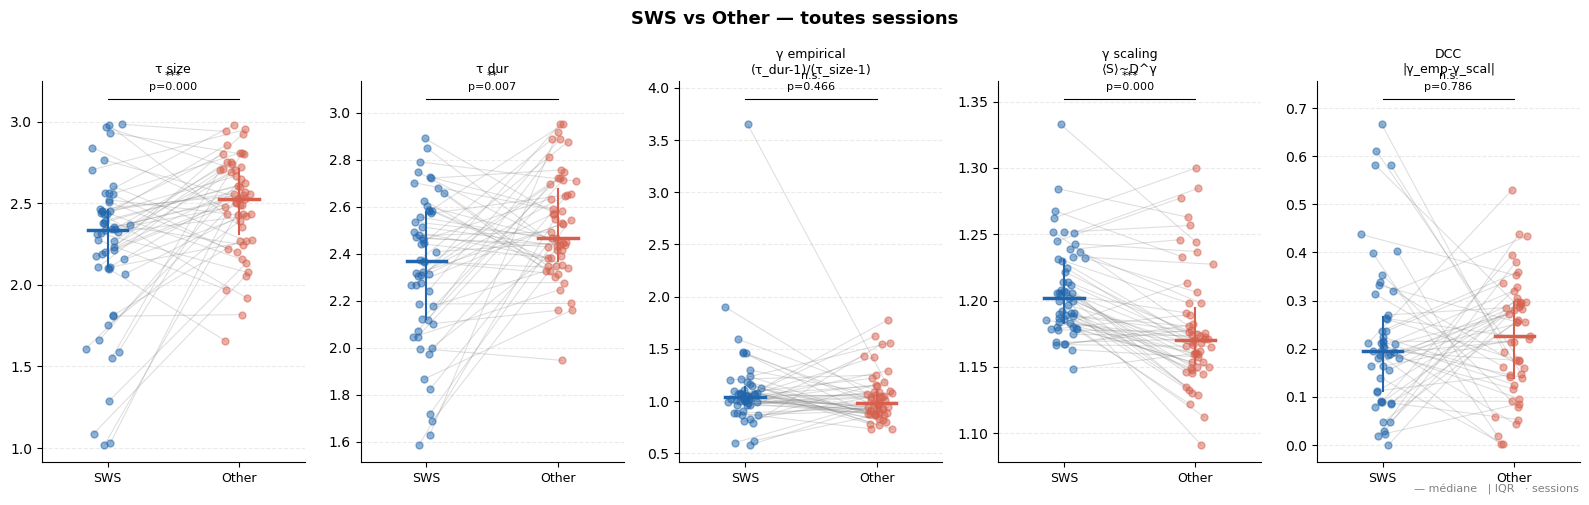

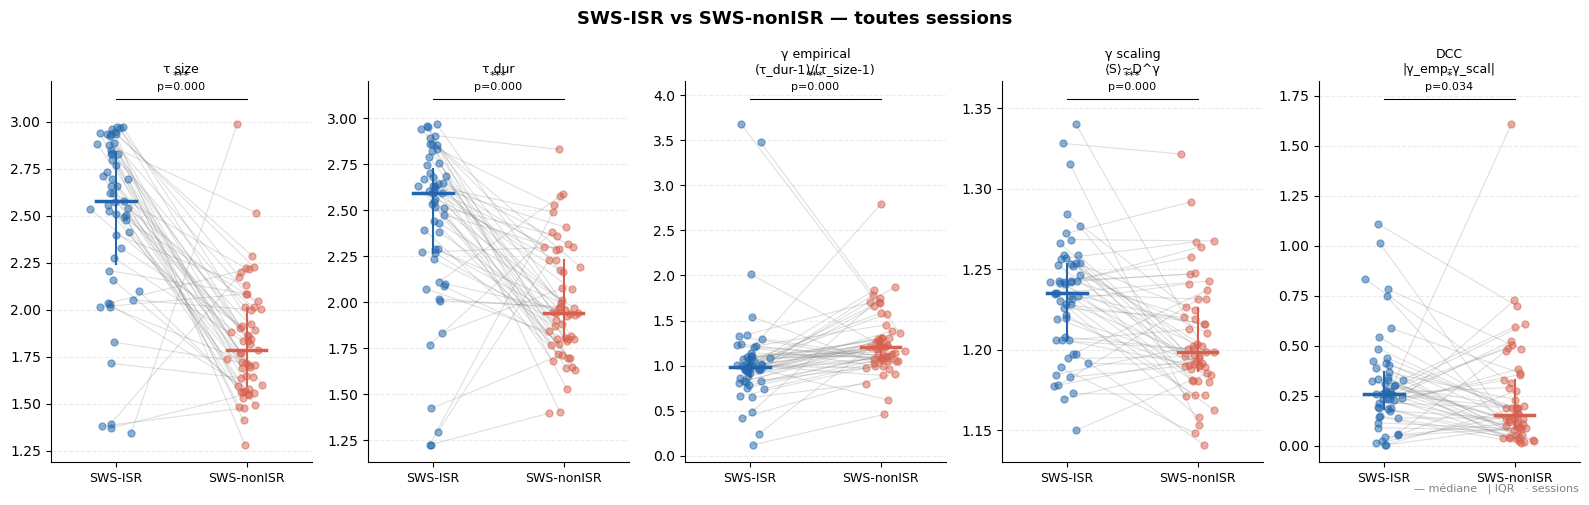

In [101]:
def plot_session_metrics(metrics_a, metrics_b, label_a, label_b, title):
    """
    metrics_a / metrics_b : dict retourné par extract_metrics()
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    keys = ["tau_size", "tau_dur", "gamma_empirical", "tau_gamma_scaling", "DCC"]
    xlabels = ["τ size", "τ dur", "γ empirical\n(τ_dur-1)/(τ_size-1)", 
               "γ scaling\n⟨S⟩~D^γ", "DCC\n|γ_emp-γ_scal|"]

    # seuils max au-delà desquels une session est exclue du plot (valeurs aberrantes)
    max_thresholds = {"gamma_empirical": 5, "DCC": 2}
    
    color_a = "#2166ac"
    color_b = "#d6604d"
    
    fig, axes = plt.subplots(1, len(keys), figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    
    for ax, key, xlabel in zip(axes, keys, xlabels):
        a = metrics_a[key]
        b = metrics_b[key]
        
        valid = np.isfinite(a) & np.isfinite(b)
        if key in max_thresholds:
            thresh = max_thresholds[key]
            valid &= (a <= thresh) & (b <= thresh)
        a_v, b_v = a[valid], b[valid]
        n = valid.sum()
        
        # ── strip plot (points individuels) ───────────────────────────
        jitter = 0.06
        x_a = np.random.normal(0, jitter, n)
        x_b = np.random.normal(1, jitter, n)
        ax.scatter(x_a, a_v, color=color_a, alpha=0.5, s=25, zorder=3)
        ax.scatter(x_b, b_v, color=color_b, alpha=0.5, s=25, zorder=3)
        
        # ── lignes pairées session par session ─────────────────────────
        for xa, xb, ya, yb in zip(x_a, x_b, a_v, b_v):
            ax.plot([xa, xb], [ya, yb], color="gray", alpha=0.25, 
                    linewidth=0.8, zorder=2)
        
        # ── médiane + IQR ──────────────────────────────────────────────
        for x_pos, vals, color in [(0, a_v, color_a), (1, b_v, color_b)]:
            med = np.nanmedian(vals)
            q25 = np.nanpercentile(vals, 25)
            q75 = np.nanpercentile(vals, 75)
            ax.plot([x_pos - 0.15, x_pos + 0.15], [med, med],
                    color=color, linewidth=2.5, zorder=4)
            ax.plot([x_pos, x_pos], [q25, q75],
                    color=color, linewidth=1.5, zorder=4)
        
        # ── Wilcoxon ──────────────────────────────────────────────────
        if n >= 5:
            from scipy.stats import wilcoxon
            try:
                _, p = wilcoxon(a_v, b_v)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
                y_max = max(np.nanmax(a_v), np.nanmax(b_v))
                y_range = y_max - min(np.nanmin(a_v), np.nanmin(b_v))
                y_bar = y_max + y_range * 0.08
                ax.plot([0, 1], [y_bar, y_bar], color="black", linewidth=0.8)
                ax.text(0.5, y_bar + y_range * 0.02, f"{sig}\np={p:.3f}",
                        ha="center", va="bottom", fontsize=8)
            except Exception:
                pass
        
        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([label_a, label_b], fontsize=9)
        ax.set_title(xlabel, fontsize=9)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)
    
    # légende médiane / IQR
    fig.text(0.99, 0.01, "— médiane   | IQR   · sessions", 
             ha="right", va="bottom", fontsize=8, color="gray")
    plt.tight_layout()
    return fig


# ── Utilisation ───────────────────────────────────────────────────────────────
fig1 = plot_session_metrics(sws_metrics, other_metrics,
                            "SWS", "Other", "SWS vs Other — toutes sessions")

fig2 = plot_session_metrics(isr_metrics, nonisr_metrics,
                            "SWS-ISR", "SWS-nonISR", "SWS-ISR vs SWS-nonISR — toutes sessions")

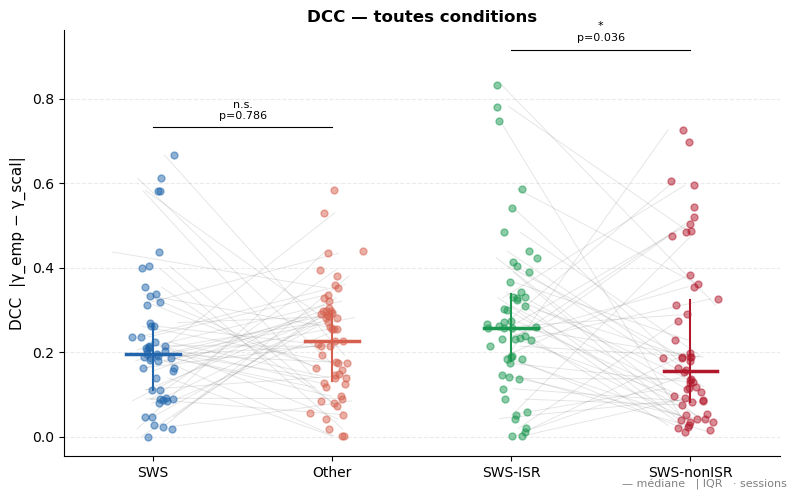

In [103]:
def plot_DCC_all_conditions(metrics_sws, metrics_other, metrics_isr, metrics_nonisr,
                             max_threshold=1):
    """
    Compare DCC across all 4 conditions on a single strip plot.
    """
    from scipy.stats import wilcoxon
    import numpy as np
    import matplotlib.pyplot as plt

    conditions = [
        (metrics_sws,     "SWS",         "#2166ac"),
        (metrics_other,   "Other",        "#d6604d"),
        (metrics_isr,     "SWS-ISR",      "#1a9850"),
        (metrics_nonisr,  "SWS-nonISR",   "#b2182b"),
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    all_dcc = []
    valid_per_cond = []

    for x_pos, (metrics, label, color) in enumerate(conditions):
        dcc = metrics["DCC"]
        valid = np.isfinite(dcc) & (dcc <= max_threshold)
        vals = dcc[valid]
        valid_per_cond.append(valid)
        all_dcc.append(vals)

        # strip plot
        jitter = np.random.normal(x_pos, 0.06, len(vals))
        ax.scatter(jitter, vals, color=color, alpha=0.5, s=25, zorder=3)

        # médiane + IQR
        med = np.nanmedian(vals)
        q25 = np.nanpercentile(vals, 25)
        q75 = np.nanpercentile(vals, 75)
        ax.plot([x_pos - 0.15, x_pos + 0.15], [med, med],
                color=color, linewidth=2.5, zorder=4)
        ax.plot([x_pos, x_pos], [q25, q75],
                color=color, linewidth=1.5, zorder=4)

    # lignes pairées SWS↔Other et ISR↔nonISR
    pair_groups = [(0, 1), (2, 3)]  # indices dans conditions
    for i, j in pair_groups:
        valid_ij = valid_per_cond[i] & valid_per_cond[j]
        a_v = metrics_sws["DCC"][valid_ij]     if i == 0 else metrics_isr["DCC"][valid_ij]
        b_v = metrics_other["DCC"][valid_ij]   if j == 1 else metrics_nonisr["DCC"][valid_ij]
        n = valid_ij.sum()
        jit_a = np.random.normal(i, 0.06, n)
        jit_b = np.random.normal(j, 0.06, n)
        for xa, xb, ya, yb in zip(jit_a, jit_b, a_v, b_v):
            ax.plot([xa, xb], [ya, yb], color="gray", alpha=0.2,
                    linewidth=0.7, zorder=2)

        # Wilcoxon sur chaque paire
        if n >= 5:
            try:
                _, p = wilcoxon(a_v, b_v)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
                y_max = max(np.nanmax(a_v), np.nanmax(b_v))
                y_range = y_max - min(np.nanmin(a_v), np.nanmin(b_v))
                y_bar = y_max + y_range * 0.1
                ax.plot([i, j], [y_bar, y_bar], color="black", linewidth=0.8)
                ax.text((i + j) / 2, y_bar + y_range * 0.02,
                        f"{sig}\np={p:.3f}", ha="center", va="bottom", fontsize=8)
            except Exception:
                pass

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([c[1] for c in conditions], fontsize=10)
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylabel("DCC  |γ_emp − γ_scal|", fontsize=11)
    ax.set_title("DCC — toutes conditions", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    fig.text(0.99, 0.01, "— médiane   | IQR   · sessions",
             ha="right", va="bottom", fontsize=8, color="gray")
    plt.tight_layout()
    return fig


# ── Utilisation ───────────────────────────────────────────────────────────────
fig = plot_DCC_all_conditions(sws_metrics, other_metrics, isr_metrics, nonisr_metrics)

In [95]:
batch_file = "/mnt/hubel-data-103/Guillaume/Code/Python/batch_5rats.batch"
# get all sessions from batch file
sessions = fma.data.readBatchFile(batch_file)[0]

In [111]:
from scipy.stats import wilcoxon, pearsonr
import numpy as np

def compare_with_cluster_check(metrics_a, metrics_b, label_a, label_b,
                                rat_per_session, title=""):
    """
    Wilcoxon apparié sur sessions + vérification de clustering par rat.
    """
    keys = ["tau_size", "tau_dur", "gamma_empirical", "tau_gamma_scaling", "DCC"]
    rat_arr = np.array(rat_per_session)

    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")
    print(f"  {'Metric':25s}  {'β (med diff)':>12}  {'p Wilcoxon':>10}  "
          f"{'Sig':>4}  {'ICC':>5}  {'n_valid':>7}")
    print(f"  {'-'*65}")

    for key in keys:
        a = metrics_a[key]
        b = metrics_b[key]
        diff = a - b
        valid = np.isfinite(diff)
        d_v = diff[valid]
        r_v = rat_arr[valid]
        n = valid.sum()

        if n < 5:
            print(f"  {key:25s}  — pas assez (n={n})")
            continue

        # Wilcoxon sur sessions
        try:
            _, p = wilcoxon(a[valid], b[valid])
            sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        except Exception:
            p, sig = np.nan, "err"

        # ICC manuel = var_entre_rats / var_totale des différences
        rat_means = np.array([d_v[r_v == r].mean() for r in np.unique(r_v)])
        var_entre = np.var(rat_means, ddof=1)
        var_totale = np.var(d_v, ddof=1)
        icc = var_entre / var_totale if var_totale > 0 else 0.0

        med_diff = np.median(d_v)

        print(f"  {key:25s}  {med_diff:>+12.4f}  {p:>10.4f}  "
              f"{sig:>4}  {icc:>5.2f}  {n:>7}")

    # ── Médiane par rat (contrôle conservateur) ───────────────────────
    print(f"\n  ── Médiane par rat (n={len(np.unique(rat_arr))}) ──")
    for key in keys:
        a = metrics_a[key]
        b = metrics_b[key]
        valid = np.isfinite(a) & np.isfinite(b)
        rats  = np.unique(rat_arr[valid])
        med_a = np.array([np.nanmedian(a[valid][rat_arr[valid]==r]) for r in rats])
        med_b = np.array([np.nanmedian(b[valid][rat_arr[valid]==r]) for r in rats])
        ok = np.isfinite(med_a) & np.isfinite(med_b)
        if ok.sum() < 3:
            continue
        try:
            _, p = wilcoxon(med_a[ok], med_b[ok])
            sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        except Exception:
            p, sig = np.nan, "err"
        print(f"  {key:25s}  "
              f"{label_a}={np.median(med_a[ok]):.3f}  "
              f"{label_b}={np.median(med_b[ok]):.3f}  "
              f"p={p:.4f} {sig}  (n={ok.sum()} rats)")


# Utilisation
compare_with_cluster_check(sws_metrics, other_metrics,
                           "SWS", "Other", rat_per_session,
                           title="SWS vs Other")

compare_with_cluster_check(isr_metrics, nonisr_metrics,
                           "SWS-ISR", "SWS-nonISR", rat_per_session,
                           title="SWS-ISR vs SWS-nonISR")


  SWS vs Other
  Metric                     β (med diff)  p Wilcoxon   Sig    ICC  n_valid
  -----------------------------------------------------------------
  tau_size                        -0.2482      0.0005   ***   0.18       55
  tau_dur                         -0.0570      0.0066    **   0.15       55
  gamma_empirical                 +0.0464      0.1774  n.s.   0.13       55
  tau_gamma_scaling               +0.0284      0.0000   ***   0.11       55
  DCC                             +0.0014      0.5134  n.s.   0.14       55

  ── Médiane par rat (n=5) ──
  tau_size                   SWS=2.312  Other=2.534  p=0.0625 n.s.  (n=5 rats)
  tau_dur                    SWS=2.341  Other=2.549  p=0.1250 n.s.  (n=5 rats)
  gamma_empirical            SWS=1.018  Other=1.013  p=1.0000 n.s.  (n=5 rats)
  tau_gamma_scaling          SWS=1.189  Other=1.167  p=0.0625 n.s.  (n=5 rats)
  DCC                        SWS=0.212  Other=0.248  p=1.0000 n.s.  (n=5 rats)

  SWS-ISR vs SWS-nonISR
  Metric 

In [112]:
# Exemple si vos sessions sont ordonnées par rat
rat_per_session = (["rat1"]*12 + ["rat2"]*14 + ["rat3"]*12 + 
                   ["rat4"]*9 + ["rat5"]*8)

compare_with_cluster_check(sws_metrics, other_metrics,
                           "SWS", "Other", rat_per_session,
                           title="SWS vs Other")

compare_with_cluster_check(isr_metrics, nonisr_metrics,
                           "SWS-ISR", "SWS-nonISR", rat_per_session,
                           title="SWS-ISR vs SWS-nonISR")


  SWS vs Other
  Metric                     β (med diff)  p Wilcoxon   Sig    ICC  n_valid
  -----------------------------------------------------------------
  tau_size                        -0.2482      0.0005   ***   0.18       55
  tau_dur                         -0.0570      0.0066    **   0.15       55
  gamma_empirical                 +0.0464      0.1774  n.s.   0.13       55
  tau_gamma_scaling               +0.0284      0.0000   ***   0.11       55
  DCC                             +0.0014      0.5134  n.s.   0.14       55

  ── Médiane par rat (n=5) ──
  tau_size                   SWS=2.312  Other=2.534  p=0.0625 n.s.  (n=5 rats)
  tau_dur                    SWS=2.341  Other=2.549  p=0.1250 n.s.  (n=5 rats)
  gamma_empirical            SWS=1.018  Other=1.013  p=1.0000 n.s.  (n=5 rats)
  tau_gamma_scaling          SWS=1.189  Other=1.167  p=0.0625 n.s.  (n=5 rats)
  DCC                        SWS=0.212  Other=0.248  p=1.0000 n.s.  (n=5 rats)

  SWS-ISR vs SWS-nonISR
  Metric 

## Structure des résultats

Chaque ligne rapporte deux tests sur la même métrique :

**Wilcoxon sur sessions (n=55)** — pour chaque session, calcule la différence `d_i = métrique_A - métrique_B`, range ces 55 différences par valeur absolue, et teste si leur distribution est symétrique autour de 0. Le β affiché est la **médiane de ces différences** (estimateur de Hodges-Lehmann), pas une moyenne. La p-value répond à : "si la condition ne changeait rien, quelle probabilité d'observer une asymétrie aussi extrême par hasard ?"

**Wilcoxon par rat (n=5)** — même principe mais sur les médianes par rat. Avec n=5, les seules p-values possibles sont 0.0625, 0.125, 0.25, 0.5, 0.75, 1.0 — le test ne peut **jamais** atteindre p<0.05 avec 5 paires, c'est une limite mathématique du test, pas un résultat négatif.

**ICC** — proportion de la variance des différences expliquée par le rat. ICC=0.18 signifie que 18% de la variabilité de l'effet SWS→Other sur τ_size est due à des différences entre rats ; le reste est de la variabilité session-à-session au sein d'un même rat.

---

## SWS vs Other — interprétation

**τ_size et τ_dur sont significativement plus faibles en SWS** (β=-0.25 et -0.06, ***/**). Les avalanches SWS ont une queue de distribution plus lourde — les grandes avalanches sont relativement plus fréquentes qu'en Other. C'est cohérent avec une dynamique SWS plus proche de la criticité (τ plus proche de 1.5 théorique).

**γ_empirical et DCC non significatifs** (p=0.18 et 0.51). Malgré la différence de τ, le rapport (τ_dur-1)/(τ_size-1) ne change pas entre états, et le DCC non plus. Cela suggère que les deux exposants changent de façon **proportionnelle** entre SWS et Other — la relation de scaling interne est préservée, seule l'amplitude des exposants change.

**τ_gamma_scaling significatif** (β=+0.028, ***) mais ICC=0.11 — effet faible et homogène entre rats.

**Conclusion SWS vs Other :** les τ diffèrent significativement au niveau session mais pas au niveau rat (puissance insuffisante avec n=5). ICC faibles (0.11-0.18) indiquent que l'effet est homogène entre rats, ce qui renforce la crédibilité biologique malgré l'absence de significativité au niveau rat.

---

## SWS-ISR vs SWS-nonISR — interprétation

C'est ici que les résultats sont les plus forts et biologiquement les plus intéressants.

**τ_size : β=+0.77 (***), τ_dur : β=+0.43 (***)** — les exposants ISR sont nettement plus grands que nonISR. Les avalanches pendant l'ISR ont une queue moins lourde : les grandes avalanches sont relativement moins fréquentes pendant l'ISR qu'en dehors, ce qui indique une dynamique **sous-critique** pendant l'ISR par rapport au reste du SWS.

**γ_empirical : β=-0.23 (***)** — le γ empirique est plus faible en ISR. Rappel : γ = (τ_dur-1)/(τ_size-1). Si τ_size augmente plus vite que τ_dur, γ diminue — c'est ce qu'on observe.

**DCC : β=+0.14 (*)** — le DCC est plus grand en ISR qu'en nonISR, ce qui signifie que la **relation de scaling est moins bien vérifiée** pendant l'ISR : l'écart entre γ_empirical et γ_scaling augmente. C'est un indicateur que le système s'éloigne de la criticité pendant l'ISR.

**τ_gamma_scaling : ICC=0.46** — c'est le seul cas où l'ICC est substantiel. 46% de la variance de l'effet ISR→nonISR sur γ_scaling est due au rat. Autrement dit, certains rats montrent un fort effet ISR sur γ_scaling, d'autres moins — hétérogénéité biologique réelle entre animaux sur cette métrique spécifique.

---

## Synthèse globale

| | SWS vs Other | ISR vs nonISR |
|---|---|---|
| τ diffèrent | oui (faible amplitude) | oui (forte amplitude) |
| Scaling préservé | oui (DCC n.s.) | non (DCC *) |
| Homogène entre rats | oui (ICC<0.2) | majoritairement oui sauf γ_scaling |
| Interprétation | SWS légèrement plus critique | ISR sous-critique vs nonISR |

**Le message principal :** l'ISR n'est pas juste "plus de SWS" — c'est un état dynamiquement distinct avec une organisation des avalanches différente, moins critique, et avec une relation de scaling moins cohérente. La comparaison SWS/Other est plus modeste et moins convaincante au niveau animal individuel.